# Velocity-Aware Geo-Indistinguishability for Multi-Modal Transportation Privacy-Preserving System

This notebook proposes a privacy-preserving system that adapts Location Privacy Protection Mechanisms (LPPMs) according to different transportation modes (e.g., walking, biking, driving, public transport). It integrates a velocity-aware geo-indistinguishability mechanism that customizes noise injection and prediction strategies to provide a fine-grained balance between privacy and utility.

## Objectives

- Transport-Mode Aware LPPM: Apply different geo-indistinguishability parameters for walking, driving, metro, etc.

- Velocity-Aware Tuning: Configure the epsilon value based on current or predicted velocity/duration/distance.

- Hourly Prediction Integration: Adjust privacy settings based on time-slot frequency usage (e.g., commuting hours).

- Attack Simulation Framework: Evaluate sensitivity to re-identification, trajectory linkage, and semantic location attacks.

- Privacy–Utility Tradeoff Analysis: Balance between service accuracy and privacy level.

In [ ]:
# contains multiple constant variables that result in a less verbose coding
import privkit as pk
import pandas as pd
import numpy as np
from datetime import datetime
from geopy.distance import geodesic
from privkit.utils import constants
import matplotlib.pyplot as plt
import seaborn as sns
from privkit.utils import (
    geo_utils,
    constants,
)
from tqdm import tqdm
import matplotlib.pyplot as plt
from IPython.display import display
import os
import json

In [11]:
# ---- Parameters ----
# id of the dataset
file = 'geolife'
# list of the id's of each ppm
ppms = ['va_gi', 'planar_laplace', 'adaptive', 'clustering']
# list of the id's of each scenario
scenarios = ['high_vu_high_vr', 'high_vu_low_vr', 'low_vu_high_vr', 'low_vu_low_vr']
# # list of transport modes
transport_modes = ['walk']


In [ ]:
# ---- Load Dataset ----
dataset = pk.datasets.GeolifeDataset()
dataset.load_dataset()
# Extract all labeled transport data
all_data = dataset.data.data  # Access the DataFrame within the LocationData object
labeled_data = all_data[all_data['label'].notnull()].copy()
# Get list of unique transport modes (e.g., 'walk', 'car', 'bus', ...)
# transport_modes = labeled_data['label'].unique()
print(f"Unique transport modes: {transport_modes}")

In [12]:
# ---- Compute Distances ----
def compute_average_dist_for_group (group):
    """
    Compute the distance for a given group of labeled data.
    """
    # Extract the latitude and longitude columns
    latitudes = group['lat'].values
    longitudes = group['lon'].values

    # Calculate the distance using geodesic
    distances = [
        geodesic((latitudes[i], longitudes[i]), (latitudes[i + 1], longitudes[i + 1])).meters
        for i in range(len(latitudes) - 1)
    ]
    
    # Return the average of distances
    return np.mean(distances) if distances else 0

In [13]:
def apply_ppm_to_scenario(ppm, location_data):
    # privacy parameter to be used in the appliance of the PPMs
    epsilon = 0.016
    
    if ppm == 'planar_laplace':
        planar_laplace = pk.PlanarLaplace(epsilon=epsilon)
        location_data = planar_laplace.execute(location_data)
        quality_loss = location_data.data.get(constants.QUALITY_LOSS)
        return location_data, quality_loss, epsilon

    elif ppm == 'clustering':
        # Dynamically calculate the clustering radius (r) based on the transport mode's distance distribution
        transport_mode = location_data.data['label'].iloc[0]
        mode_data = labeled_data[labeled_data['label'] == transport_mode]
        
        if not mode_data.empty:
            # Compute the 90th percentile of distances for the transport mode
            distances = mode_data.groupby(['uid', 'tid']).apply(compute_average_dist_for_group)
            r = np.percentile(distances, 90)  # Use the 90th percentile as the clustering radius
            # Redefine epsilon based on the calculated radius
            epsilon = np.log(4) / r
            print(f"Using: epsilon={epsilon}, r={r} for transport mode: {transport_mode}")
        else:
            print(f"Transport mode '{transport_mode}' not found in the dataset. Using default values.")
            r = np.log(4) / epsilon
        
        clustering = pk.ClusteringGeoInd(r=r, epsilon=epsilon)
        location_data = clustering.execute(location_data)
        quality_loss = location_data.data.get(constants.QUALITY_LOSS)
        return location_data, quality_loss, epsilon

    elif ppm == 'adaptive':
        ws = 2
        delta1 = 124.29
        delta2 = 428.56
        adaptive = pk.AdaptiveGeoInd(epsilon=epsilon, ws=ws, delta1=delta1, delta2=delta2)
        location_data = adaptive.execute(location_data)
        quality_loss = location_data.data.get(constants.QUALITY_LOSS)
        return location_data, quality_loss, epsilon

    elif ppm == 'va_gi':
        m = 10
        va_gi = pk.VAGI(epsilon=epsilon, m=m)
        location_data, quality_loss = va_gi.execute(location_data)
        return location_data, quality_loss, epsilon

    return None, None, None


In [10]:
# ---- Main Execution ----
# Loop over each transport mode
for transport_mode in tqdm(transport_modes, desc="Transport Modes"):
    print(f"[INFO] Processing transport mode: {transport_mode}")
    
    # Filter data for this transport mode
    mode_data = labeled_data[labeled_data['label'] == transport_mode].reset_index(drop=True)
    
    # Wrap into LocationData object
    location_data_per_transport_mode = pk.LocationData(id_name=transport_mode)
    location_data_per_transport_mode.data = mode_data
    
    # Iterate over every pair of scenario and ppm with tqdm for better progress tracking
    for scenario in tqdm(scenarios, desc=f"Scenarios for {transport_mode}", leave=False):
        for ppm in tqdm(ppms, desc=f"PPMs for {scenario}", leave=False):
            # Load data
            location_data = pk.LocationData('{}_{}'.format(scenario, ppm))
            location_data.data = location_data_per_transport_mode.data.copy()
            
            # Apply PPM to the scenario
            location_data, quality_loss_values, epsilon = apply_ppm_to_scenario(ppm, location_data)
            
            if quality_loss_values is not None:            

                # Save quality loss values
                filepath = '{}{}/{}/{}/'.format(constants.output_folder, file, transport_mode, ppm)
                # Ensure the directory exists
                os.makedirs(filepath, exist_ok=True)
                filename = 'ql_{}_e{}'.format(scenario, int(epsilon * 1000))
                np.save(filepath + filename, quality_loss_values)
                print(f"[INFO] Quality loss values saved for {transport_mode}, {scenario} with {ppm}.")
            else:
                print(f"[WARNING] No quality loss values returned for {transport_mode}, {scenario} with {ppm}.")
            
             # Save the modified location data for each transport mode in JSON format
            if location_data is not None:
                mode_filepath = filepath + '{}_{}_{}.json'.format(transport_mode, scenario, ppm)
                location_data.data.to_json(mode_filepath, orient='records', lines=True)
                print(f"[INFO] Location data saved for transport mode: {transport_mode}, scenario: {scenario}, PPM: {ppm}.")
            else:
                print(f"[WARNING] No location data returned for transport mode: {transport_mode}, scenario: {scenario}, PPM: {ppm}.")

Using: epsilon=0.017901007073135605, r=77.4422553689915 for transport mode: walk
[INFO] Quality loss values saved for walk, high_vu_high_vr with clustering.


[INFO] Location data saved for transport mode: walk, scenario: high_vu_high_vr, PPM: clustering.


Using: epsilon=0.017901007073135605, r=77.4422553689915 for transport mode: walk
[INFO] Quality loss values saved for walk, high_vu_low_vr with clustering.


[INFO] Location data saved for transport mode: walk, scenario: high_vu_low_vr, PPM: clustering.


Using: epsilon=0.017901007073135605, r=77.4422553689915 for transport mode: walk
[INFO] Quality loss values saved for walk, low_vu_high_vr with clustering.


[INFO] Location data saved for transport mode: walk, scenario: low_vu_high_vr, PPM: clustering.


Using: epsilon=0.017901007073135605, r=77.4422553689915 for transport mode: walk
[INFO] Quality loss values saved for walk, low_vu_low_vr with clustering.




Transport Modes: 100%|██████████| 1/1 [09:48<00:00, 588.68s/it]

[INFO] Location data saved for transport mode: walk, scenario: low_vu_low_vr, PPM: clustering.


### Comparision with original data: Loading the original data for futher comparision
We now load all the original data for better understanding of velocity/duration/distance.

In [14]:
# Compute the distance for each group
def compute_dist_for_group(grp):
    lats = grp['lat'].tolist()
    lons = grp['lon'].tolist()
    if len(lats) < 2:
        return 0
    return geo_utils.compute_trace_distance(lats, lons)

In [15]:
# --- Load the dataset again to compute distance, duration, and velocity of original data ---
def compute_mobility_metrics(location_data):
    """
    Calculate distance, duration và velocity for pk.LocationData object.
    
    Parameters:
        - location_data: pk.LocationData object 
    
    Returns:
        - df: DataFrame update distance, duration, velocity
        - transport_stats: DataFrame due to transport mode
    """
   # --- Load the dataset again to compute distance, duration, and velocity of original data ---
    df = location_data.copy()
    df = df[df['label'].notnull()]

    # Grouping data by user and trajectory
    # grouped_data = location_data.get_trajectories()
    # Calculating distance, duration, and velocity for each trajectory 
    df['duration'] = (
        df
        .groupby(['uid','tid','label'])['datetime']
        .transform(lambda x: (x.max() - x.min()).total_seconds())
    )

    distance_per_group = df.groupby(['uid','tid','label']).apply(compute_dist_for_group)
    df['distance'] = df.set_index(['uid','tid','label']).index.map(distance_per_group)



    df['velocity'] = df.apply(
        lambda row: row['distance'] / row['duration'] if row['duration'] > 0 else 0,
        axis=1
    )

    # Grouping the dataset by transport mode and calculating statistics 
    user_stats = df.groupby(['uid', 'label']).agg({
        'distance': ['mean', 'max', 'std'],
        'duration': ['mean', 'max', 'std'],
        'velocity': ['mean', 'max', 'std']
    }).reset_index()

    transport_stats = df.groupby('label').agg({
        'distance': ['mean', 'max', 'std'],
        'duration': ['mean', 'max', 'std'],
        'velocity': ['mean', 'max', 'std']
    }).reset_index()

    # Renaming the columns for clarity
    transport_stats.columns = ['Transport_Mode', 'Dist_Mean', 'Dist_Max', 'Dist_Std',
                            'Dur_Mean', 'Dur_Max', 'Dur_Std',
                            'Vel_Mean', 'Vel_Max', 'Vel_Std']

    # Printing the dataset with calculated fields
    print("\nDataset with calculated fields:")
    display(df[['uid', 'datetime', 'lat', 'lon', 'label', 'distance', 'duration', 'velocity']])

    # Printing the statistics grouped by transport mode
    print("\n📊 Statistics grouped by Transport Mode:")
    display(transport_stats)

    return user_stats, transport_stats, df

In [8]:

# --- Function for analyzing and plotting statistics ---
def plot_transport_statistics(transport_stats, scenario, ppm):
    """
    Analyze and plot statistics of transport data.
    
    Parameters:
        - scenario: Name of the privacy scenario
        - ppm: Name of the privacy-preserving mechanism
    """
    

    plt.figure(figsize=(10, 6))
    sns.barplot(data=transport_stats, x='Transport_Mode', y='Vel_Mean', palette='coolwarm')
    plt.title(f'Average Velocity by Transport Mode\n[{scenario} - {ppm}]')
    plt.ylabel('Velocity (m/s)')
    plt.xlabel('Transport Mode')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=transport_stats, x='Transport_Mode', y='Dist_Mean', palette='viridis')
    plt.title(f'Average Distance by Transport Mode\n[{scenario} - {ppm}]')
    plt.ylabel('Distance (m)')
    plt.xlabel('Transport Mode')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=transport_stats, x='Transport_Mode', y='Dur_Mean', palette='plasma')
    plt.title(f'Average Duration by Transport Mode\n[{scenario} - {ppm}]')
    plt.ylabel('Duration (seconds)')
    plt.xlabel('Transport Mode')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [7]:
# --- Generating the result of the original data ---
# Extracting the location data
original_location_data = dataset.data
# Compute the mobility metrics for the original data
# user_stats, transport_stats, grouped_data = compute_mobility_metrics(original_location_data)
# # Plotting the statistics for the original data
# plot_transport_statistics(original_location_data, 'original', 'none')

## Analysis of the possibility of revealing transportation means thanks to velocity/duration/distance 
We now analyse the transport mode could be revealed even have been obfusciated by privacy-preserving mechanism thanks to the calculation of velocity/duration/distance of all obfusciated points.

In [16]:
def load_obfuscated_data(transport_modes, scenarios, ppms, base_folder, file_prefix):
    """
    Load all obfuscated JSON files into pk.LocationData objects, separated by transport mode.
    
    Parameters:
        - transport_modes: List of transport modes (e.g., ['walk', 'bike'])
        - scenarios: List of scenario names (e.g., ['high_privacy', 'medium_privacy'])
        - ppms: List of PPM names (e.g., ['random', 'dp', 'geo-indist'])
        - base_folder: Root folder where output is saved (e.g., constants.output_folder)
        - file_prefix: Subfolder or run name (e.g., 'run1')
    
    Returns:
        - data_dict: Nested dictionary of LocationData objects indexed by [scenario][ppm][transport_mode].
    """
    data_dict = {}

    def load_file(filepath, scenario, ppm, transport_mode):
        try:
            location_data = pk.LocationData(id_name=f"{scenario}_{ppm}_{transport_mode}")
            location_data.data = pd.read_json(filepath, orient='records', lines=True)
            return location_data
        except Exception as e:
            print(f"[ERROR] Failed to load {filepath}: {e}")
            return None

    for scenario in scenarios:
        data_dict[scenario] = {}
        for ppm in ppms:
            data_dict[scenario][ppm] = {}
            for transport_mode in transport_modes:
                filename = f"{transport_mode}_{scenario}_{ppm}.json"
                filepath = os.path.join(base_folder, file_prefix, transport_mode, ppm, filename)

                if os.path.exists(filepath):
                    location_data = load_file(filepath, scenario, ppm, transport_mode)
                    if location_data:
                        data_dict[scenario][ppm][transport_mode] = location_data
                        print(f"[INFO] Loaded: {filepath}")
                else:
                    print(f"[WARNING] File not found: {filepath}")

    return data_dict


In [ ]:
# Define base_folder and file_prefix
base_folder = constants.output_folder  # Assuming constants.output_folder is the correct base folder
file_prefix = file 
# --- Load the obfuscated data ---
data_dict = load_obfuscated_data(transport_modes, scenarios, ppms, base_folder, file_prefix)

# --- Process each scenario ---
for scenario in scenarios:
    for ppm in ppms:
        for transport_mode in transport_modes:
            location_data = data_dict[scenario][ppm].get(transport_mode)
            if location_data:
                # Compare with original data
                common_pairs = set(zip(original_location_data.data['uid'], original_location_data.data['tid'])) & \
                         set(zip(location_data.data['uid'], location_data.data['tid']))

                for uid, tid in common_pairs:
                    traj_orig = original_location_data.data[(original_location_data.data['uid'] == uid) & (original_location_data.data['tid'] == tid)]
                    traj_obf = location_data.data[(location_data.data['uid'] == uid) & (location_data.data['tid'] == tid)]

                    if traj_orig.empty or traj_obf.empty:
                        continue

                    plt.figure(figsize=(10, 6))
                    plt.plot(traj_orig['lon'], traj_orig['lat'], marker='o', linestyle='-', markersize=3, label='Original', color='blue')
                    plt.plot(traj_obf['lon'], traj_obf['lat'], marker='x', linestyle='--', markersize=3, label='Obfuscated', color='red')
                    plt.title(f'UID {uid} - TID {tid}\nScenario: {scenario}, PPM: {ppm}')
                    plt.xlabel('Longitude')
                    plt.ylabel('Latitude')
                    plt.legend()
                    plt.grid(True)
                    plt.show()


In [ ]:
# Define base_folder and file_prefix
base_folder = constants.output_folder  # Assuming constants.output_folder is the correct base folder
file_prefix = file 
# --- Load the obfuscated data ---
data_dict = load_obfuscated_data(transport_modes, scenarios, ppms, base_folder, file_prefix)

# --- Create the output folder for mobility metrics ---
metrics_output_folder = os.path.join(base_folder, "mobility_metrics")
os.makedirs(metrics_output_folder, exist_ok=True)
json_file = os.path.join(metrics_output_folder, "all_mobility_metrics.json")
# Initialize a dictionary to store all metrics
if os.path.exists(json_file) and os.path.getsize(json_file) > 0:
    with open(json_file, 'r') as f:
        all_metrics = json.load(f)
else:
    all_metrics = {}
    
# --- Process each scenario ---
for scenario in scenarios:
    for ppm in ppms:
        for transport_mode in transport_modes:
            location_data = data_dict[scenario][ppm].get(transport_mode)
            if location_data:
                user_stats, transport_stats, grouped_data = compute_mobility_metrics(location_data)
                # Convert column names to strings to avoid TypeError
                transport_stats.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else col for col in transport_stats.columns]

                transport_stats_json = transport_stats.to_dict(orient='records')

                all_metrics.setdefault(str(scenario), {}).setdefault(str(ppm), {})[str(transport_mode)] = {
                    "transport_stats": transport_stats_json,
                }
                # Saving the statistics to JSON
                with open(json_file, 'w') as f:
                    json.dump(all_metrics, f, indent=2)
                # Printng the saving information
                print(f"[INFO] Statistics saved for {transport_mode}, {scenario} with {ppm}.")
            else:
                print(f"[WARNING] No location data returned for transport mode: {transport_mode}, scenario: {scenario}, PPM: {ppm}.")
                

In [4]:
# --- Load the saved mobility metrics from JSON ---
def load_mobility_metrics(json_file):
    """
    Load mobility metrics from a JSON file.
    
    Parameters:
        - json_file: Path to the JSON file containing mobility metrics.
    
    Returns:
        - all_metrics: Dictionary containing all mobility metrics.
    """
    if os.path.exists(json_file) and os.path.getsize(json_file) > 0:
        with open(json_file, 'r') as f:
            all_metrics = json.load(f)
        return all_metrics
    else:
        print(f"[ERROR] JSON file {json_file} does not exist or is empty.")
        return {}

In [ ]:
# --- Load the mobility metrics from the JSON file ---
base_folder = constants.output_folder  # Assuming constants.output_folder is the correct base folder
file_prefix = file 
metrics_output_folder = os.path.join(base_folder, "mobility_metrics")
os.makedirs(metrics_output_folder, exist_ok=True)
json_file = os.path.join(metrics_output_folder, "all_mobility_metrics.json")
all_metrics = load_mobility_metrics(json_file)
# --- Plotting the mobility metrics for each scenario and PPM and combine to all transport mode---
for scenario in scenarios:
    for ppm in ppms:
        transport_stats = pd.DataFrame()
        for transport_mode in transport_modes:
            if str(scenario) in all_metrics and str(ppm) in all_metrics[str(scenario)] and str(transport_mode) in all_metrics[str(scenario)][str(ppm)]:
                stats = all_metrics[str(scenario)][str(ppm)][str(transport_mode)]['transport_stats']
                temp_df = pd.DataFrame(stats)
                temp_df['Transport_Mode'] = transport_mode
                transport_stats = pd.concat([transport_stats, temp_df], ignore_index=True)
        # display(transport_stats)
        # Plotting the statistics for each scenario and PPM
        plot_transport_statistics(transport_stats, scenario, ppm)

## Privacy–Utility Tradeoff Analysis: Visualizing the Results
We now present a simple script that generates a *matplotlib* box plot graph, showing the behavior of each scenario under the different PPMs. 


[PLOT] Generating plot for transport mode: walk
[WARNING] File not found: ./output/geolife/walk/va_gi/ql_high_vu_high_vr_e17.npy
[WARNING] File not found: ./output/geolife/walk/adaptive/ql_high_vu_high_vr_e16.npy
[WARNING] File not found: ./output/geolife/walk/va_gi/ql_high_vu_low_vr_e13.npy
[WARNING] File not found: ./output/geolife/walk/adaptive/ql_high_vu_low_vr_e16.npy
[WARNING] File not found: ./output/geolife/walk/va_gi/ql_low_vu_high_vr_e13.npy
[WARNING] File not found: ./output/geolife/walk/adaptive/ql_low_vu_high_vr_e16.npy
[WARNING] File not found: ./output/geolife/walk/va_gi/ql_low_vu_low_vr_e13.npy
[WARNING] File not found: ./output/geolife/walk/adaptive/ql_low_vu_low_vr_e16.npy


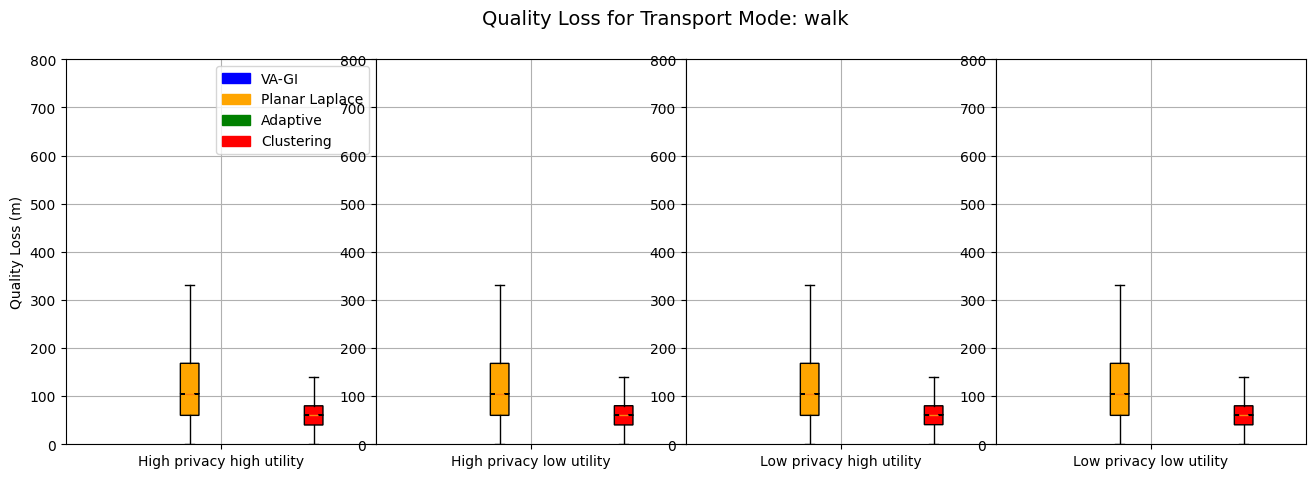

In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# scenarios labels
scenarios_labels = [r'$\uparrow v_u \downarrow v_r$', 
                    r'$\downarrow v_u \downarrow v_r$', 
                    r'$\uparrow v_u \uparrow v_r$', 
                    r'$\downarrow v_u \uparrow v_r$']

# ppms colors
colors = ['blue', 'orange', 'green', 'red']

# ppms labels
ppms_labels = ['VA-GI', 'Planar Laplace', 'Adaptive', 'Clustering']

# set epsilon value (for file naming)
epsilon_laplace = 0.016
epsilon_clustering = 0.013

# senarios labels
scenarios_labels = ['High privacy high utility',
                    'High privacy low utility',
                    'Low privacy high utility',
                    'Low privacy low utility']
# Iterate over each transport_mode
for transport_mode in transport_modes:
    print(f"[PLOT] Generating plot for transport mode: {transport_mode}")
    
    # Initialize figure with 4 subplots (1 for each scenario)
    plt.figure(figsize=(16, 5))
    plt.suptitle(f'Quality Loss for Transport Mode: {transport_mode}', fontsize=14)

    for index, (scenario, scenario_label) in enumerate(zip(scenarios, scenarios_labels)):
        plt.subplot(1, 4, index + 1)

        # Load quality loss data for each PPM
        ql_data = []
        for ppm in ppms:
            if ppm == 'planar_laplace':
                epsilon = epsilon_laplace
            elif ppm == 'clustering':
                epsilon = epsilon_clustering
            filepath = f'{constants.output_folder}{file}/{transport_mode}/{ppm}/ql_{scenario}_e{int(epsilon*1000)}.npy'
            if os.path.exists(filepath):
                data = np.load(filepath)
                ql_data.append(data)
            else:
                print(f"[WARNING] File not found: {filepath}")
                ql_data.append([])

        # Plot boxplots for each PPM
        boxplots = []
        for i, data in enumerate(ql_data):
            bp = plt.boxplot(data, positions=[-1 + i*2/3], widths=0.20, notch=True,
                             patch_artist=True, showfliers=False)
            boxplots.append(bp)

        # Set colors
        for plot, color in zip(boxplots, colors):
            for patch in plot['boxes']:
                patch.set_facecolor(color)

        # Labeling
        plt.xticks(np.arange(0, 2, 2), [scenario_label])
        plt.axis(xmin=-2, xmax=2)
        plt.xlim([-1-2/3, 1+2/3])
        plt.ylim([0, 800])
        plt.grid(True)

    # Add ylabel to first subplot
    plt.subplot(1, 4, 1)
    plt.ylabel('Quality Loss (m)')

    # Add legend
    handles = [mpatches.Patch(color=color, label=label) for color, label in zip(colors, ppms_labels)]
    plt.legend(handles=handles, loc='upper right')

    plt.subplots_adjust(wspace=.0)
    plt.show()


We now analysis the labeled changes to understand better the performance of privacy in the dataset.

In [ ]:
# --- Calculate the obfuscated labeled data distribution compared to original ones ---
def calculate_labeled_data_distribution(location_data, transport_modes):
    """
    Calculate the distribution of labeled data for each transport mode.
    
    Parameters:
        - location_data: pk.LocationData object containing the data.
        - transport_modes: List of transport modes to consider.
    
    Returns:
        - distribution: Dictionary with transport modes as keys and their counts as values.
    """
    distribution = {}
    for mode in transport_modes:
        count = len(location_data.data[location_data.data['label'] == mode])
        distribution[mode] = count
    return distribution

# --- Define base_folder and file_prefix ---
base_folder = constants.output_folder  # Assuming constants.output_folder is the correct base folder
file_prefix = file 

# --- Load the obfuscated data ---
data_dict = load_obfuscated_data(transport_modes, scenarios, ppms, base_folder, file_prefix)

# --- Calculate the original labeled data distribution ---
original_data = dataset.data
original_distribution = calculate_labeled_data_distribution(original_data, transport_modes)

# --- Calculate the obfuscated labeled data distribution for each scenario and PPM ---
obfuscated_distribution = {}
# Iterate through each scenario and PPM
for scenario in scenarios:
    obfuscated_distribution[scenario] = {}
    for ppm in ppms:
        obfuscated_distribution[scenario][ppm] = {}
        for transport_mode in transport_modes:
            location_data = data_dict[scenario][ppm].get(transport_mode)
            if location_data:
                distribution = calculate_labeled_data_distribution(location_data, transport_modes)
                obfuscated_distribution[scenario][ppm][transport_mode] = distribution
            else:
                print(f"[WARNING] No location data returned for transport mode: {transport_mode}, scenario: {scenario}, PPM: {ppm}.")


In [ ]:
# --- Plotting the labeled data distribution for original and obfuscated data ---
def plot_labeled_data_distribution(original_distribution, obfuscated_distribution, transport_modes):
    """
    Plot the distribution of labeled data for original and obfuscated datasets.
    
    Parameters:
        - original_distribution: Dictionary with original labeled data distribution.
        - obfuscated_distribution: Nested dictionary with obfuscated labeled data distribution.
        - transport_modes: List of transport modes to consider.
    """
    # Create a DataFrame for original distribution
    original_df = pd.DataFrame.from_dict(original_distribution, orient='index', columns=['Original'])
    
    # Create a DataFrame for obfuscated distribution
    obfuscated_df = pd.DataFrame()
    for scenario in obfuscated_distribution:
        for ppm in obfuscated_distribution[scenario]:
            temp_df = pd.DataFrame(obfuscated_distribution[scenario][ppm]).sum(axis=1).rename(f'{scenario}_{ppm}')
            obfuscated_df = pd.concat([obfuscated_df, temp_df], axis=1)
    
    # Combine both DataFrames
    combined_df = pd.concat([original_df, obfuscated_df], axis=1).fillna(0)
    
    # Plotting
    combined_df.plot(kind='bar', figsize=(12, 6))
    plt.title('Labeled Data Distribution')
    plt.xlabel('Transport Modes')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(loc='upper right')
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
# --- Plot the labeled data distribution ---
plot_labeled_data_distribution(original_distribution, obfuscated_distribution, transport_modes)

In [ ]:
# --- One particular use case (userid &tid) is to compare the original and obfuscated data in one trajectory has been obfuscated the labeled data ---
def compare_trajectories(original_data, obfuscated_data, uid, tid):
    """
    Compare the original and obfuscated trajectories for a specific user and trajectory ID.
    
    Parameters:
        - original_data: pk.LocationData object containing the original data.
        - obfuscated_data: pk.LocationData object containing the obfuscated data.
        - uid: User ID to filter the data.
        - tid: Trajectory ID to filter the data.
    """
    orig_traj = original_data.data[(original_data.data['uid'] == uid) & (original_data.data['tid'] == tid)]
    obf_traj = obfuscated_data[(obfuscated_data['uid'] == uid) & (obfuscated_data['tid'] == tid)]
    
    if orig_traj.empty or obf_traj.empty:
        print(f"[WARNING] No trajectory found for UID {uid}, TID {tid}.")
        return
    
    plt.figure(figsize=(12, 6))
    plt.plot(orig_traj['lon'], orig_traj['lat'], marker='o', linestyle='-', markersize=3, label=f"Original ({orig_traj['label'].iloc[0]})", color='blue')
    plt.plot(obf_traj['obf_lon'], obf_traj['obf_lat'], marker='x', linestyle='--', markersize=3, label=f"Obfuscated ({obf_traj['label'].iloc[0]})", color='red')
    plt.title(f'Comparison of Original and Obfuscated Trajectories\nUID: {uid}, TID: {tid}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.show()
# --- Example usage of compare_trajectories function ---
uid = 167  # Example user ID
tid = 343  # Example trajectory ID
# Compare trajectories for each scenario and PPM    
for scenario in scenarios:
    for ppm in ppms:
        # Get obfuscated data for the specific uid and tid within the transport mode
        obfuscated_data = data_dict[scenario][ppm].get(transport_mode)
        print(obfuscated_data.data)
        if obfuscated_data is not None and obfuscated_data.data is not None:
            obfuscated_data = obfuscated_data.data[(obfuscated_data.data['uid'] == uid) & (obfuscated_data.data['tid'] == tid)]
            compare_trajectories(original_data, obfuscated_data, uid, tid)
        else:
            print(f"[WARNING] No obfuscated data found for scenario: {scenario}, PPM: {ppm}.")

In [ ]:
# --- Calculate velocity, duration, and distance for the original data for this particular usecase ---
orig_traj = original_data.data[(original_data.data['uid'] == uid) & (original_data.data['tid'] == tid)]
orig_user_stats, orig_transport_stats, orig_traj = compute_mobility_metrics(orig_traj)
# --- Calculate velocity, duration, and distance for the obfuscated data for this particular usecase ---
obf_traj = obfuscated_data[(obfuscated_data['uid'] == uid) & (obfuscated_data['tid'] == tid)]
obf_user_stats, obf_transport_stats, obf_traj = compute_mobility_metrics(obf_traj)

In [ ]:
# --- Plotting the velocity, duration, and distance for original and obfuscated data ---
def plot_velocity_duration_distance(orig_traj, obf_traj):
    """
    Plot the velocity, duration, and distance for original and obfuscated trajectories.
    
    Parameters:
        - orig_traj: DataFrame with original trajectory data.
        - obf_traj: DataFrame with obfuscated trajectory data.
    """
    fig, axs = plt.subplots(3, 1, figsize=(12, 15))
    
    # Plot Velocity
    axs[0].plot(orig_traj['datetime'], orig_traj['velocity'], label='Original Velocity', color='blue')
    axs[0].plot(obf_traj['datetime'], obf_traj['velocity'], label='Obfuscated Velocity', color='red')
    axs[0].set_title('Velocity Comparison')
    axs[0].set_ylabel('Velocity (m/s)')
    axs[0].legend()
    
    # Plot Duration
    axs[1].plot(orig_traj['datetime'], orig_traj['duration'], label='Original Duration', color='blue')
    axs[1].plot(obf_traj['datetime'], obf_traj['duration'], label='Obfuscated Duration', color='red')
    axs[1].set_title('Duration Comparison')
    axs[1].set_ylabel('Duration (seconds)')
    axs[1].legend()
    
    # Plot Distance
    axs[2].plot(orig_traj['datetime'], orig_traj['distance'], label='Original Distance', color='blue')
    axs[2].plot(obf_traj['datetime'], obf_traj['distance'], label='Obfuscated Distance', color='red')
    axs[2].set_title('Distance Comparison')
    axs[2].set_ylabel('Distance (meters)')
    axs[2].legend()
    
    plt.xlabel('Time')
    plt.tight_layout()
    plt.show()
# --- Example usage of plot_velocity_duration_distance function ---
plot_velocity_duration_distance(orig_traj, obf_traj)